In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Lecture du fichier (séparateur virgule)
df = pd.read_csv("../../data/data_churn.txt", sep=",")

# Aperçu
print(df.shape)
df.head()


(528883, 34)


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.0,1969.0,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.0,1290627.0,10954600.0,4.5,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,20040930.0,1960.0,PPH,BR114,LR,...,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20260102.0,NaN,NaN,NaN,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,20040930.0,1969.0,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251227.0,1380527.0,113593077.0,4.5,CURRENT,Retail,4
3,C318650,A0257995,TN,TN,M,20040930.0,1969.0,PPH,BR114,LR,...,ACCOUNTS,BANK.CUR.ACCT.ALL.TOURS.CARTE,Compte Allocation Touristique TND,NaN,NaN,0.0,NaN,NaN,Retail,4
4,C318648,A0312991,TN,TN,M,20040930.0,1960.0,PPH,BR114,LR,...,NaN,NaN,DEPOTS A TERME,NaN,NaN,NaN,NaN,NaN,Retail,4


In [15]:
# Types de colonnes
print(df.dtypes)

# Valeurs manquantes
print(df.isnull().sum())

# Doublons
print(df.duplicated().sum())


CUSTOMER_NO              str
ACCOUNT_NO               str
NATIONALITY              str
RESIDENCE                str
MARITAL_STATUS           str
CUST_OPENING_DATE    float64
DATE_OF_BIRTH        float64
NATURE_CLIENT            str
BRANCH                   str
SCORE_KYC                str
COMPLETED_FILE           str
LAST_REVIEW_DATE     float64
NEXT__REVIEW_DATE    float64
ACCOUNT_STATUS           str
ACCT_OPENING_DATE    float64
ACCOUNT_CATEGORY     float64
ACCOUNT_TYPE_DESC        str
CURRENCY                 str
ACCT_CLOSE_DATE      float64
CLOSURE_REASON           str
ACCT_BALANCE         float64
INDUSTRY               int64
SALARY               float64
PRODUCT_GROUP            str
PRODUCT_LINE             str
PRODUCT                  str
ACCOUNTNATURE            str
STARTDATE            float64
MATURITYDATE         float64
AMOUNT               float64
FIXEDRATE            float64
PRODUCT_STATUS           str
PARTYCLASS               str
LOB                    int64
dtype: object


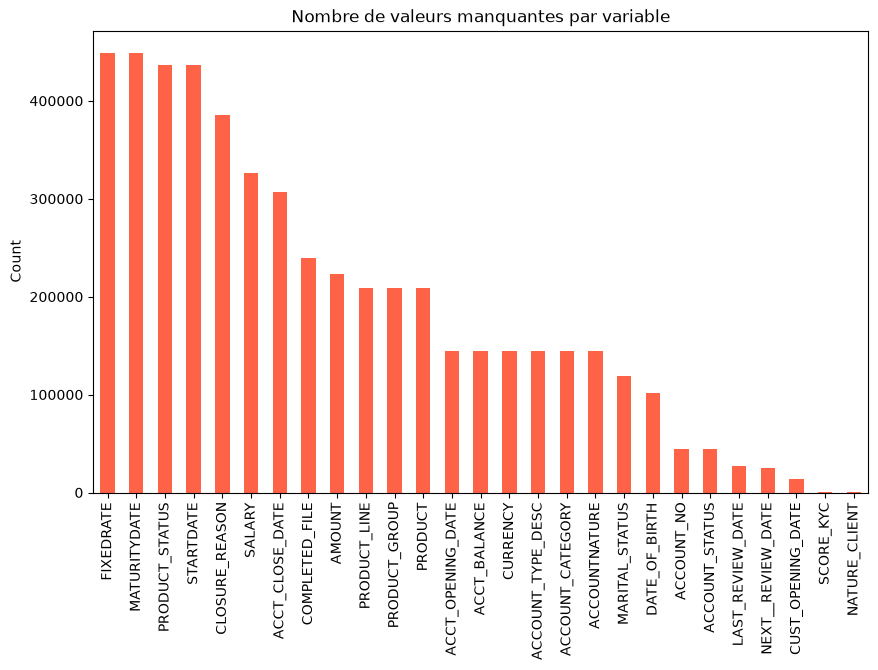

In [16]:
# Calcul du nombre de valeurs manquantes par colonne
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.plot(kind="bar", color="tomato")
plt.title("Nombre de valeurs manquantes par variable")
plt.ylabel("Count")
plt.show()


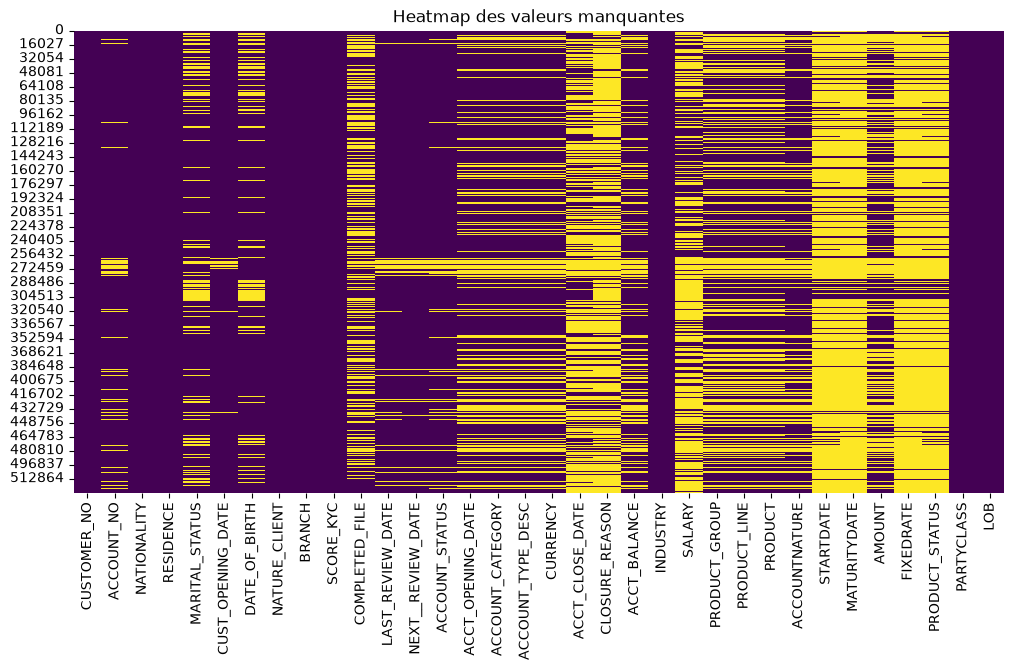

In [17]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap des valeurs manquantes")
plt.show()


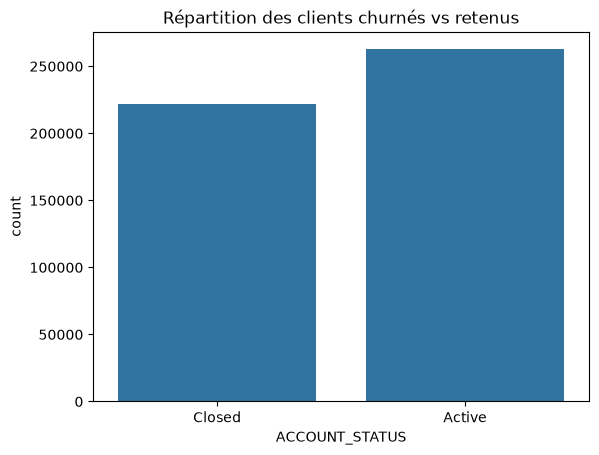

,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
count,528883,484443,528883,528883,410185,5.152610e+05,427568.000000,528805,528883,528038,...,320037,320037,383958,9.272700e+04,7.955000e+04,3.053630e+05,79548.000000,92723,528883,528883.000000
unique,363569,410587,141,137,4,NaN,NaN,9,142,5,...,4,225,149,NaN,NaN,NaN,NaN,7,5,NaN
top,C155581,A0164634,TN,TN,M,NaN,NaN,PPH,BR114,LR,...,ACCOUNTS,BANK.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,NaN,NaN,CURRENT,Retail,NaN
freq,8091,93,509824,494836,219232,NaN,NaN,374968,26573,342717,...,225817,178236,178236,NaN,NaN,NaN,NaN,62781,394876,NaN
mean,NaN,NaN,NaN,NaN,NaN,2.013615e+07,1976.250122,NaN,NaN,NaN,...,NaN,NaN,NaN,6.270502e+06,3.980789e+06,4.129769e+07,8.654123,NaN,NaN,6.062354
std,NaN,NaN,NaN,NaN,NaN,6.802723e+04,17.291827,NaN,NaN,NaN,...,NaN,NaN,NaN,8.375982e+06,6.629582e+06,4.428026e+08,2.488265,NaN,NaN,5.462568
min,NaN,NaN,NaN,NaN,NaN,1.996012e+07,1190.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,1.131130e+06,-1.900000e+07,-4.382312e+07,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,2.007082e+07,1964.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,1.251225e+06,1.260318e+06,7.080000e+00,8.330000,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,2.014092e+07,1977.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,1.251231e+06,1.261205e+06,1.510595e+03,9.330000,NaN,NaN,4.000000
75%,NaN,NaN,NaN,NaN,NaN,2.019111e+07,1989.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,2.025053e+07,1.341031e+06,1.490000e+05,10.080000,NaN,NaN,4.000000


In [18]:
# Distribution de la variable cible
sns.countplot(x="ACCOUNT_STATUS", data=df)
plt.title("Répartition des clients churnés vs retenus")
plt.show()

# Statistiques descriptives
df.describe(include="all")


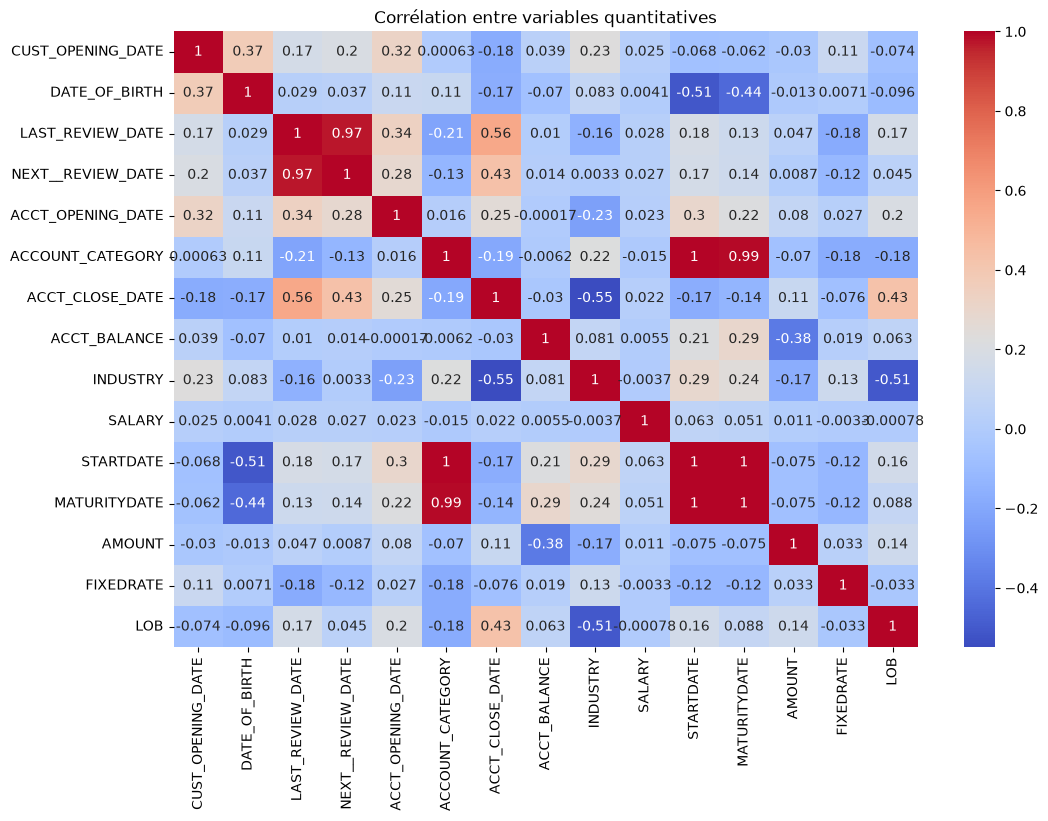

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques
df_num = df.select_dtypes(include=["int64", "float64"])

# Calculer la corrélation
corr_matrix = df_num.corr()

# Afficher la matrice
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Corrélation entre variables quantitatives")
plt.show()


## 🚨 Détection d’anomalies dans les corrélations

Lors de l’analyse des variables quantitatives, certaines corrélations apparaissent inhabituelles ou incohérentes :

- Des variables temporelles (ex. `CUST_OPENING_DATE`, `ACCT_OPENING_DATE`, `MATURITYDATE`) présentent des corrélations très fortes entre elles, ce qui peut indiquer une redondance ou un problème de codage des dates.
- La variable `ACCOUNT_CATEGORY` apparaît dans la matrice alors qu’elle semble être catégorielle. Son encodage numérique peut fausser l’interprétation.
- Certaines corrélations négatives extrêmes (proches de -1) suggèrent soit une relation inversée stricte, soit une anomalie dans la structuration des données.

### ✅ Recommandations
- Vérifier le type et le format des colonnes (dates, catégories encodées).
- Contrôler la qualité des données sources pour éviter les doublons ou les colonnes mal typées.
- Écarter ou transformer les variables redondantes avant la modélisation afin d’éviter la multicolinéarité.


In [20]:
# Variables quantitatives
df_quanti = df.select_dtypes(include=["int64", "float64"])
print("Variables quantitatives :", df_quanti.columns.tolist())
# Variables qualitatives (string + category)
df_quali = df.select_dtypes(include=["string", "category"])
print("Variables qualitatives :", df_quali.columns.tolist())

Variables quantitatives : ['CUST_OPENING_DATE', 'DATE_OF_BIRTH', 'LAST_REVIEW_DATE', 'NEXT__REVIEW_DATE', 'ACCT_OPENING_DATE', 'ACCOUNT_CATEGORY', 'ACCT_CLOSE_DATE', 'ACCT_BALANCE', 'INDUSTRY', 'SALARY', 'STARTDATE', 'MATURITYDATE', 'AMOUNT', 'FIXEDRATE', 'LOB']
Variables qualitatives : ['CUSTOMER_NO', 'ACCOUNT_NO', 'NATIONALITY', 'RESIDENCE', 'MARITAL_STATUS', 'NATURE_CLIENT', 'BRANCH', 'SCORE_KYC', 'COMPLETED_FILE', 'ACCOUNT_STATUS', 'ACCOUNT_TYPE_DESC', 'CURRENCY', 'CLOSURE_REASON', 'PRODUCT_GROUP', 'PRODUCT_LINE', 'PRODUCT', 'ACCOUNTNATURE', 'PRODUCT_STATUS', 'PARTYCLASS']


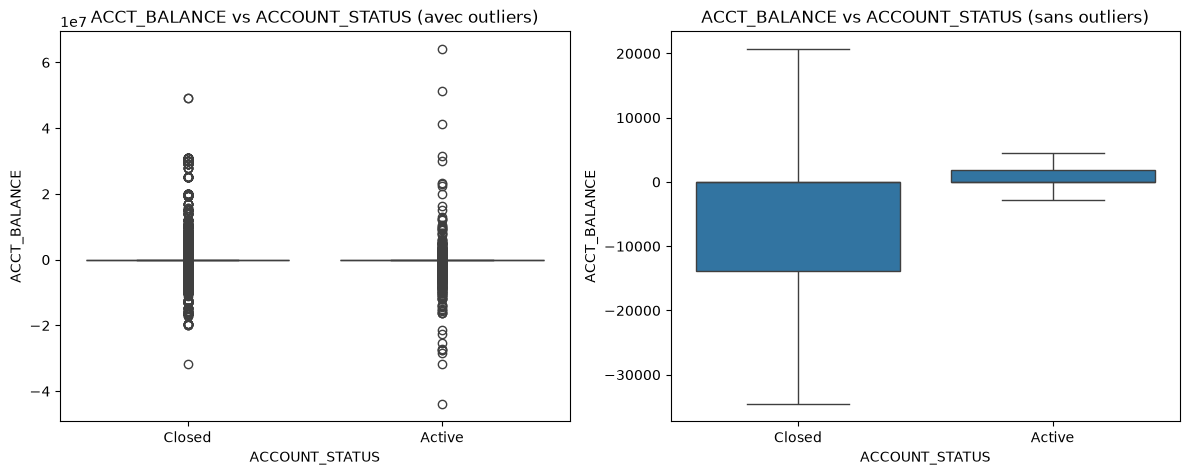

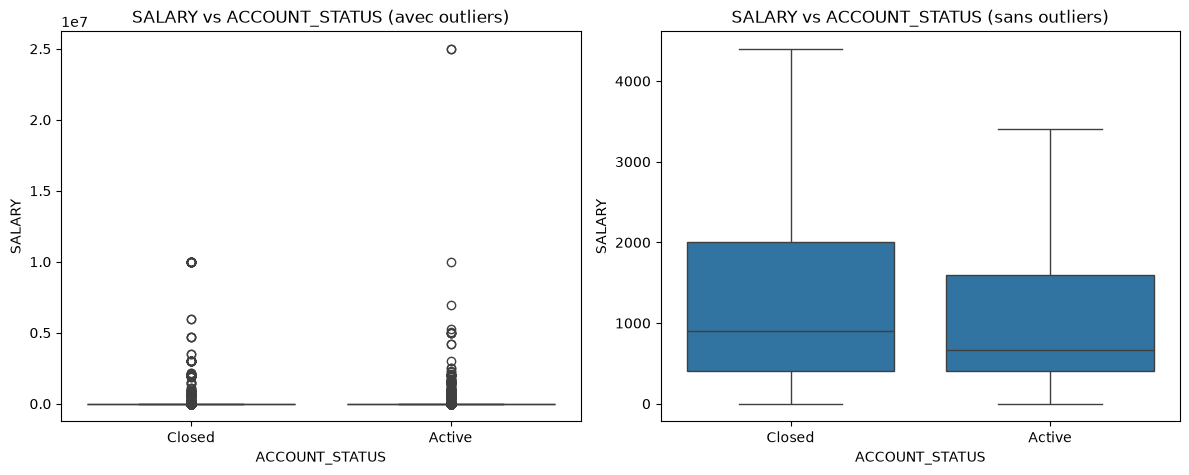

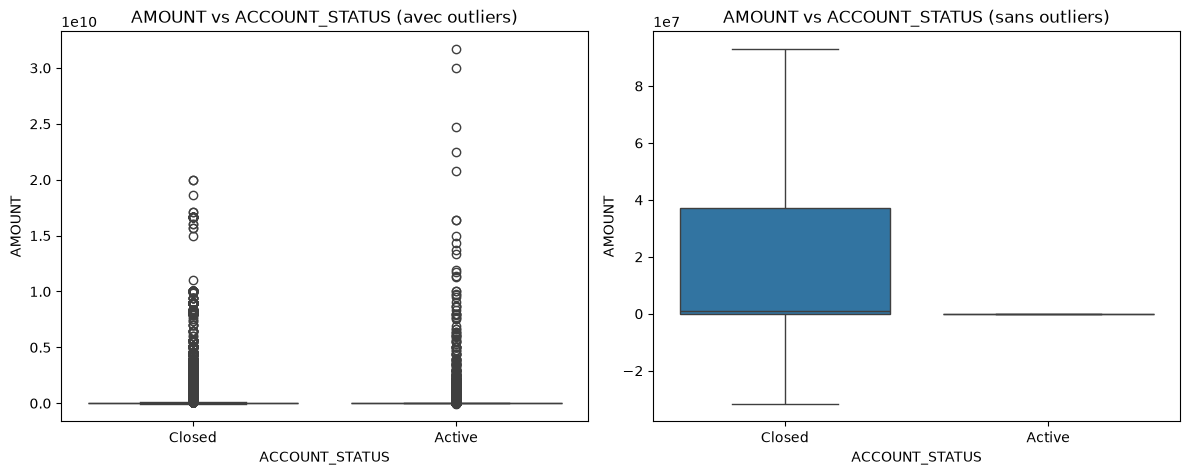

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

df_quanti_confirmed = ["ACCT_BALANCE", "SALARY", "AMOUNT"]

for col in df_quanti_confirmed:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Boxplot avec outliers
    sns.boxplot(x="ACCOUNT_STATUS", y=col, data=df, ax=axes[0], showfliers=True)
    axes[0].set_title(f"{col} vs ACCOUNT_STATUS (avec outliers)")

    # Boxplot sans outliers
    sns.boxplot(x="ACCOUNT_STATUS", y=col, data=df, ax=axes[1], showfliers=False)
    axes[1].set_title(f"{col} vs ACCOUNT_STATUS (sans outliers)")

    plt.tight_layout()
    plt.show()


In [22]:
print("Variables qualitatives :", df_quali.columns.tolist())

Variables qualitatives : ['CUSTOMER_NO', 'ACCOUNT_NO', 'NATIONALITY', 'RESIDENCE', 'MARITAL_STATUS', 'NATURE_CLIENT', 'BRANCH', 'SCORE_KYC', 'COMPLETED_FILE', 'ACCOUNT_STATUS', 'ACCOUNT_TYPE_DESC', 'CURRENCY', 'CLOSURE_REASON', 'PRODUCT_GROUP', 'PRODUCT_LINE', 'PRODUCT', 'ACCOUNTNATURE', 'PRODUCT_STATUS', 'PARTYCLASS']


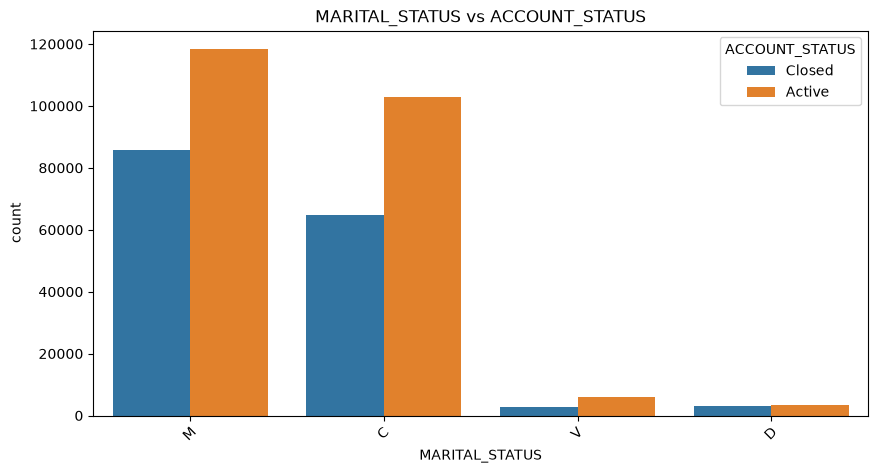

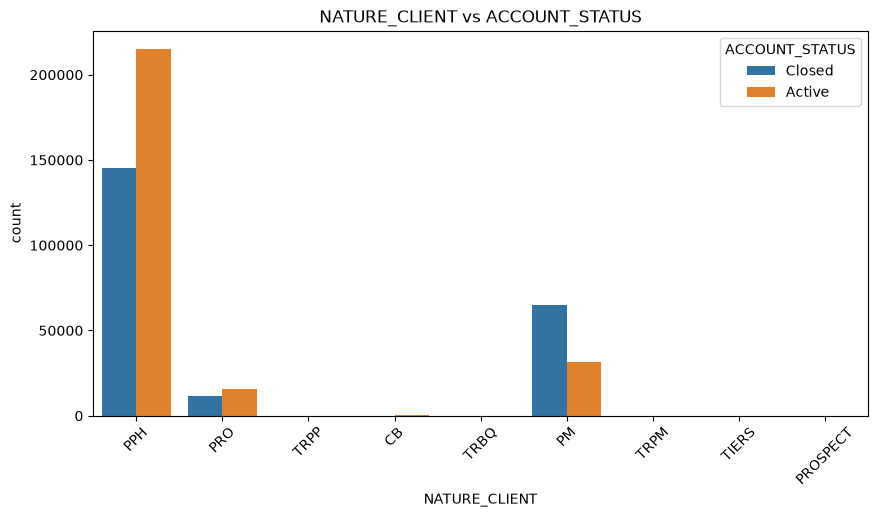

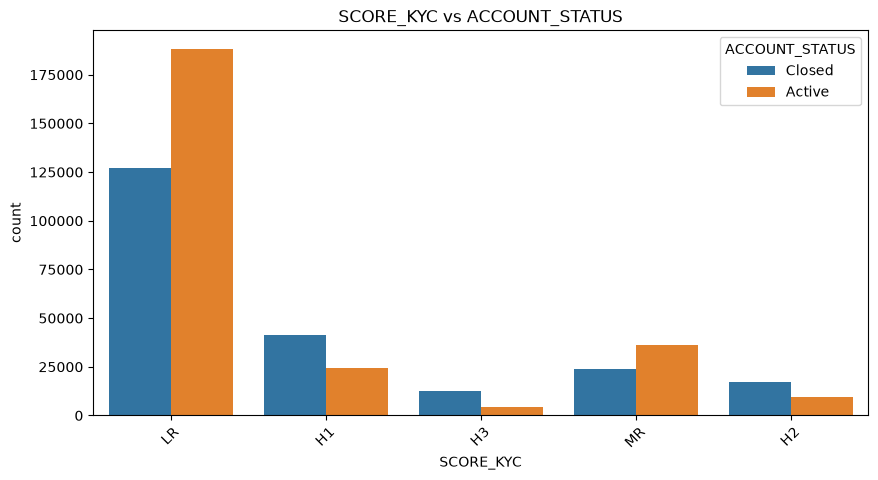

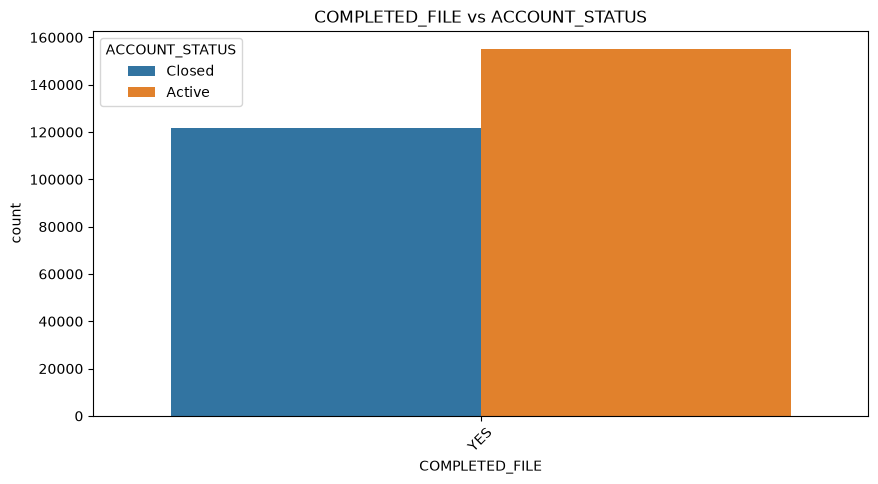

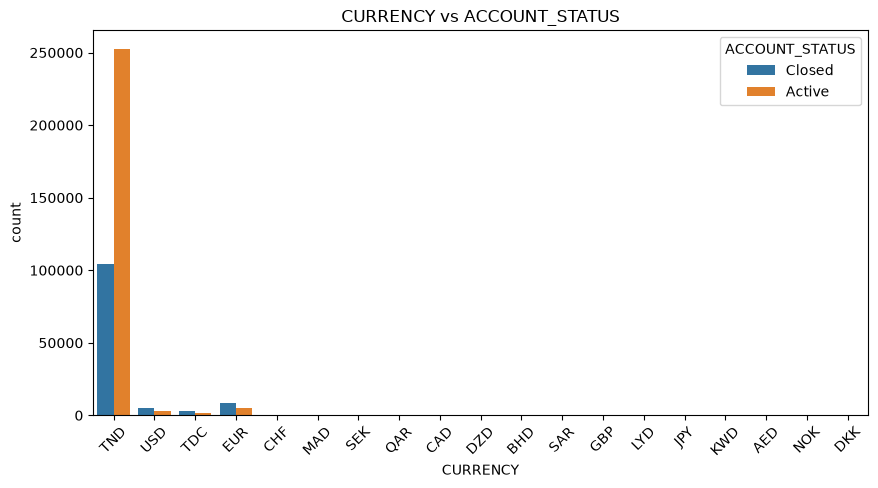

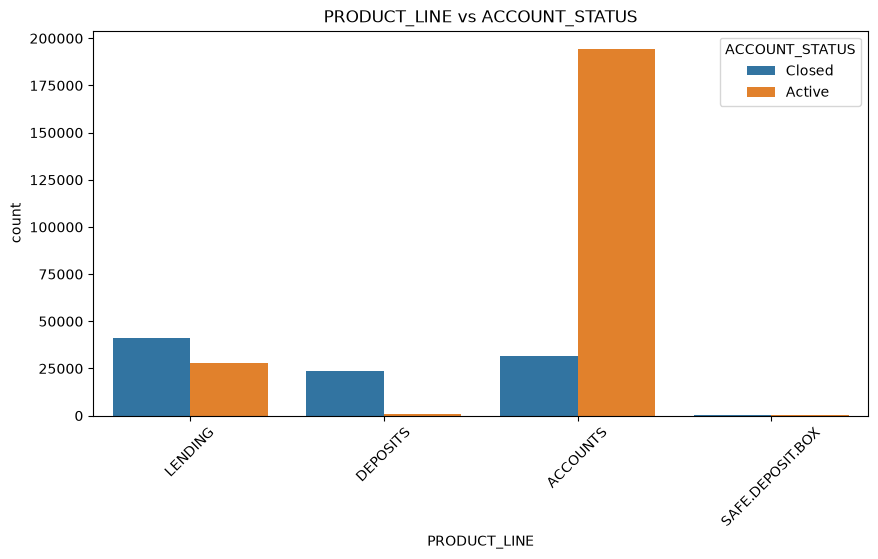

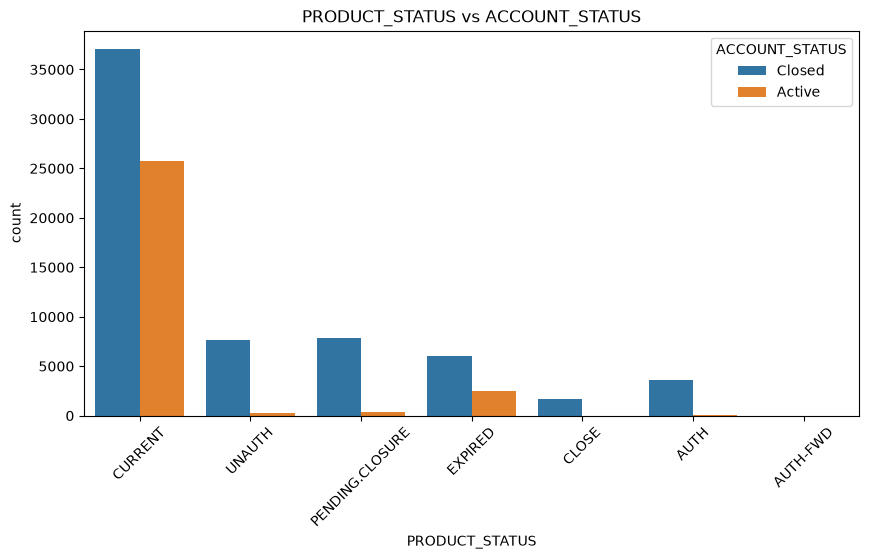

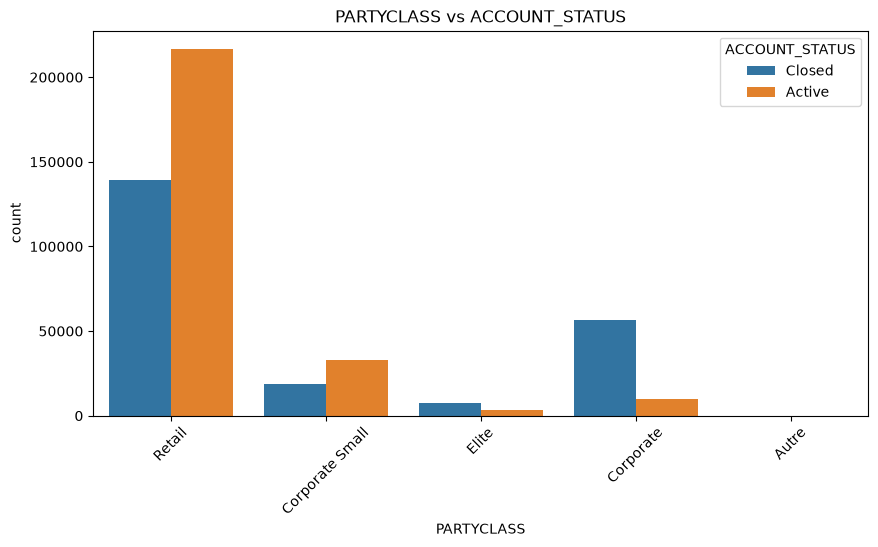

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

qual_vars = [
    'MARITAL_STATUS','NATURE_CLIENT','SCORE_KYC',
    'COMPLETED_FILE','CURRENCY','PRODUCT_LINE',
    'PRODUCT_STATUS','PARTYCLASS'
]

for col in qual_vars:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, hue="ACCOUNT_STATUS", data=df)
    plt.title(f"{col} vs ACCOUNT_STATUS")
    plt.xticks(rotation=45)
    plt.show()


In [24]:
# Sélectionner les colonnes contenant "DATE" dans leur nom
date_cols = df.filter(like="DATE").columns.tolist()
print("Colonnes avec 'DATE' :", date_cols)
df[date_cols].head()




Colonnes avec 'DATE' : ['CUST_OPENING_DATE', 'DATE_OF_BIRTH', 'LAST_REVIEW_DATE', 'NEXT__REVIEW_DATE', 'ACCT_OPENING_DATE', 'ACCT_CLOSE_DATE', 'STARTDATE', 'MATURITYDATE']


,CUST_OPENING_DATE,DATE_OF_BIRTH,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCT_OPENING_DATE,ACCT_CLOSE_DATE,STARTDATE,MATURITYDATE
0,20040930.0,1969.0,20250905.0,20290905.0,20190827.0,20260128.0,1251227.0,1290627.0
1,20040930.0,1960.0,20250905.0,20290905.0,20260105.0,20250630.0,20260102.0,NaN
2,20040930.0,1969.0,20250905.0,20290905.0,20230612.0,20260128.0,1251227.0,1380527.0
3,20040930.0,1969.0,20250905.0,20290905.0,20220527.0,20260128.0,NaN,NaN
4,20040930.0,1960.0,20250905.0,20290905.0,20250702.0,20250630.0,NaN,NaN


## ⚠️ Problème détecté dans les variables de type DATE

Lors de l’exploration des colonnes suivantes :
- `CUST_OPENING_DATE`
- `DATE_OF_BIRTH`
- `LAST_REVIEW_DATE`
- `NEXT__REVIEW_DATE`
- `ACCT_OPENING_DATE`
- `ACCT_CLOSE_DATE`
- `STARTDATE`
- `MATURITYDATE`

### 🚨 Anomalies constatées
- Les valeurs apparaissent sous forme **numérique flottante** (ex. `20040930.0`, `1969.0`) au lieu d’un format date (`YYYY-MM-DD`).
- Certaines colonnes contiennent des **valeurs incohérentes** :
  - `DATE_OF_BIRTH` avec des années seules (`1969.0`, `1960.0`) au lieu de dates complètes.
  - `STARTDATE` et `MATURITYDATE` avec des nombres non conformes (`1251227.0`, `1290627.0`).
- Présence de **valeurs manquantes** (`NaN`) dans plusieurs colonnes (`MATURITYDATE`, `STARTDATE`, `ACCT_CLOSE_DATE,...`).

### ✅ Recommandations
- Convertir les colonnes en type `datetime` avec `pd.to_datetime()`, en précisant le format (`%Y%m%d`).
- Vérifier les colonnes qui ne respectent pas le format attendu (`DATE_OF_BIRTH`, `STARTDATE`, `MATURITYDATE`) et corriger ou exclure les valeurs aberrantes.
- Traiter les valeurs manquantes (`NaN`) par imputation ou suppression selon la pertinence métier.


In [29]:
df["CLOSURE_REASON"]

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
528878    NaN
528879    NaN
528880    NaN
528881    NaN
528882    NaN
Name: CLOSURE_REASON, Length: 528883, dtype: str